
# Blending and Pasting Images

For some computer vision systems, we'll want to be able to post our own image on top of an already existing image or video. We may also want to blend images, maybe we want to have a "highlight" effect instead of just a solid box or empty rectangle.

Let's explore what is commonly known as **Arithmetic Image Operations** with OpenCV. These are referred to as Arithmetic Operations because OpenCV is simply performing some common math with the pixels for the final effect. We'll see a bit of this in our code.

## Blending Images

Blending Images is actually quite simple, let's look at a simple example.

In [42]:
import cv2

In [40]:
# Two images
imgdogpack = cv2.imread('dog_backpack.png')
imgwatermark = cv2.imread('watermark_no_copy.png')

In [41]:
imgdogpack.shape

(1401, 934, 3)

In [18]:
imgwatermark.shape

(1280, 1277, 3)

In [43]:
import matplotlib.pyplot as plt
%matplotlib inline

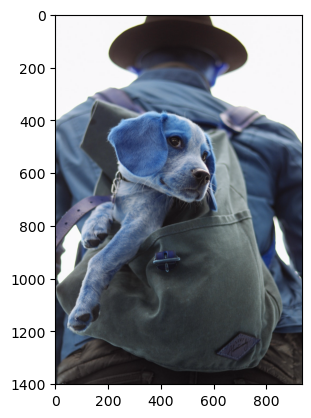

In [44]:
plt.imshow(imgdogpack)

In [64]:
imgdogpack = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
imgwatermark = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

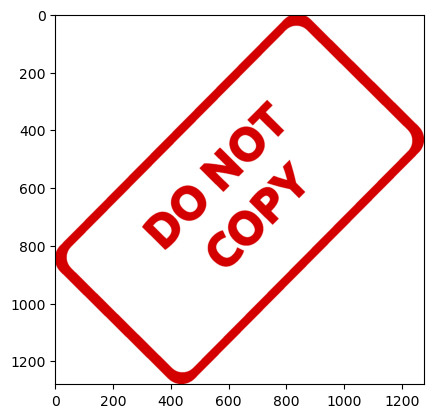

In [65]:
plt.imshow(imgwatermark)

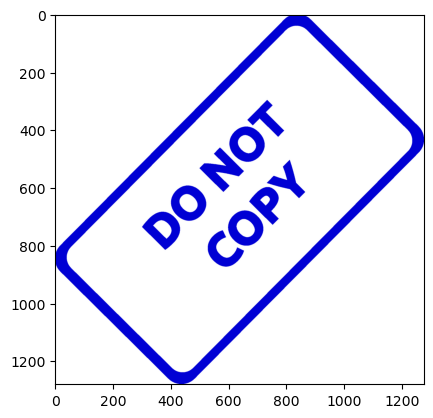

In [46]:
plt.imshow(imgwatermark)

### Resizing the Images

In [61]:
imgdpresize =cv2.resize(imgdogpack,(1200,1200))
imgwmresize =cv2.resize(imgwatermark,(1200,1200))

Let's practice resizing the image, since the DO NOT COPY image is actually quite large 1200 by 1200, and our puppy in backpack image is 1400 by 1000

Verify those matrix dimensions!!!

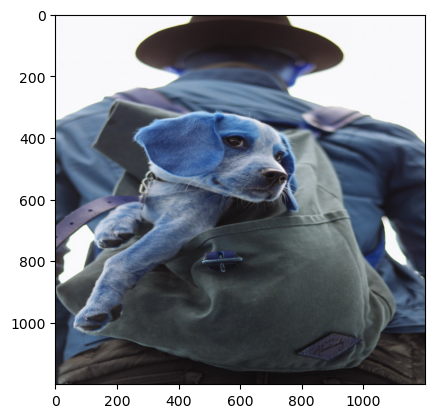

In [62]:
plt.imshow(imgdpresize)

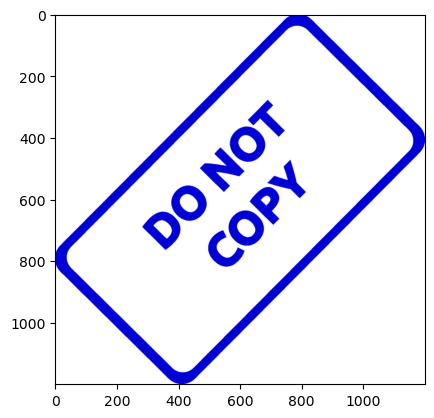

In [26]:
plt.imshow(imgwmresize)

Fix those figures above -> color

### Blending the Image

We will blend the values together with the formula:

$$  img1 * \alpha  + img2 * \beta  + \gamma $$

Okay, let's start this off by explaning the meaning of $\alpha, \beta$ and $\gamma$. 

Write down your understanding about those parameters.

In [27]:
imgdpresize.shape

(1200, 1200, 3)

In [28]:
imgwmresize.shape

(1200, 1200, 3)

In [63]:
blended = cv2.addWeighted(src1=img1,alpha=0.7,src2=img2,beta=0.3,gamma=0)

error: OpenCV(4.8.0) /io/opencv/modules/core/src/arithm.cpp:647: error: (-209:Sizes of input arguments do not match) The operation is neither 'array op array' (where arrays have the same size and the same number of channels), nor 'array op scalar', nor 'scalar op array' in function 'arithm_op'


#### Can you solve this message error? 

please refer documentation: https://docs.opencv.org/4.x/d2/de8/group__core__array.html#gafafb2513349db3bcff51f54ee5592a19

In [70]:
blended = cv2.addWeighted(src1=imgdpresize,alpha=0.3,src2=imgwmresize,
                          beta=0.8,gamma=0.8)

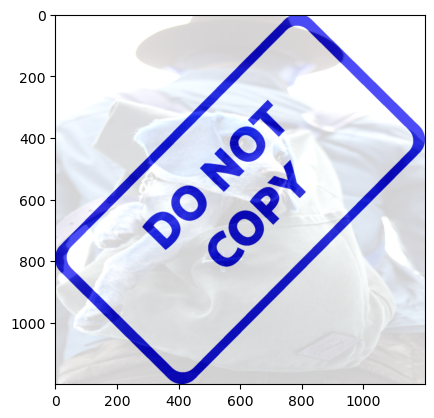

In [71]:
plt.imshow(blended)

-----

## Overlaying Images of Different Sizes

We can use this quick trick to quickly overlap different sized images, by simply reassigning the larger image's values to match the smaller image.

In [72]:
# Load two images
img1 = cv2.imread('dog_backpack.png')
img2 = cv2.imread('watermark_no_copy.png')
img2rsz =cv2.resize(img2,(600,600))

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2rsz = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

large_img = img1
small_img = img2rsz

In [35]:
x_offset=0
y_offset=0

In [38]:
large_img[y_offset:y_offset+small_img.shape[0], x_offset:x_offset+small_img.shape[1]] = small_img

ValueError: could not broadcast input array from shape (1280,1277,3) into shape (1280,934,3)

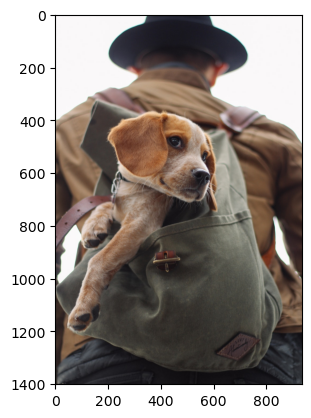

In [39]:
plt.imshow(large_img)